In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set up visual parameters for presentation-ready plots
%matplotlib inline
sns.set_theme(style="ticks")
plt.rcParams['figure.figsize'] = (10, 6)

print("Setup complete! Libraries imported and visual environment set.")

Setup complete! Libraries imported and visual environment set.


In [3]:
# Loading your local 'car_data.csv' file

df_cars = pd.read_csv("car_data.csv")
print("--- Kaggle car_data.csv Loaded Successfully ---")



--- Kaggle car_data.csv Loaded Successfully ---


In [4]:
df_cars.head()


,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [6]:
# 1. Feature Engineering: Convert manufacturing 'Year' to 'Car_Age' (Current Year - Year)
df_cars['Car_Age'] = 2026 - df_cars['Year']

# 2. Define the target variable (Selling_Price)
y = df_cars['Selling_Price']

# 3. Separate features into categorical and numerical types
# We drop 'Car_Name' because it has too many unique values, and 'Year' since we engineered 'Car_Age'
selected_numerical = ['Present_Price', 'Driven_kms', 'Owner', 'Car_Age']
selected_categorical = ['Fuel_Type', 'Selling_type', 'Transmission']

X = df_cars[selected_numerical + selected_categorical]

print("\n--- Processed Feature Matrix (X) Preview ---")
X.head()


--- Processed Feature Matrix (X) Preview ---


,Present_Price,Driven_kms,Owner,Car_Age,Fuel_Type,Selling_type,Transmission
0,5.59,27000,0,12,Petrol,Dealer,Manual
1,9.54,43000,0,13,Diesel,Dealer,Manual
2,9.85,6900,0,9,Petrol,Dealer,Manual
3,4.15,5200,0,15,Petrol,Dealer,Manual
4,6.87,42450,0,12,Diesel,Dealer,Manual


In [7]:

# Set 80% for training and 20% for testing validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training feature set dimension: {X_train.shape}")
print(f"Testing feature set dimension:  {X_test.shape}")

Training feature set dimension: (240, 7)
Testing feature set dimension:  (61, 7)


In [8]:

# Numerical Pipeline: Standardize scales to handle variance between Driven_kms and Present_Price
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Categorical Pipeline: Convert text labels into binary column vectors
categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

# Assemble processing steps using ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, selected_numerical),
        ('cat', categorical_transformer, selected_categorical)
    ]
)

# Bundle preprocessor with Gradient Boosting Regressor model
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42))
])

print("Preprocessing pipeline and regression model successfully integrated!")

Preprocessing pipeline and regression model successfully integrated!


In [9]:

print("--- Training Gradient Boosting Regressor ---")
model_pipeline.fit(X_train, y_train)
print("Model training operation completed successfully!")

--- Training Gradient Boosting Regressor ---
Model training operation completed successfully!


In [10]:

# Predict prices using test subset features
y_pred = model_pipeline.predict(X_test)

# Calculate key model performance regression metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("=================== EVALUATION METRICS ===================")
print(f"Mean Absolute Error (MAE)     : {mae:.2f} Lakhs")
print(f"Root Mean Squared Error (RMSE) : {rmse:.2f} Lakhs")
print(f"R-squared Accuracy (R²)        : {r2 * 100:.2f}%")
print("==========================================================")

=================== EVALUATION METRICS ===================
Mean Absolute Error (MAE)     : 0.59 Lakhs
Root Mean Squared Error (RMSE) : 0.94 Lakhs
R-squared Accuracy (R²)        : 96.17%


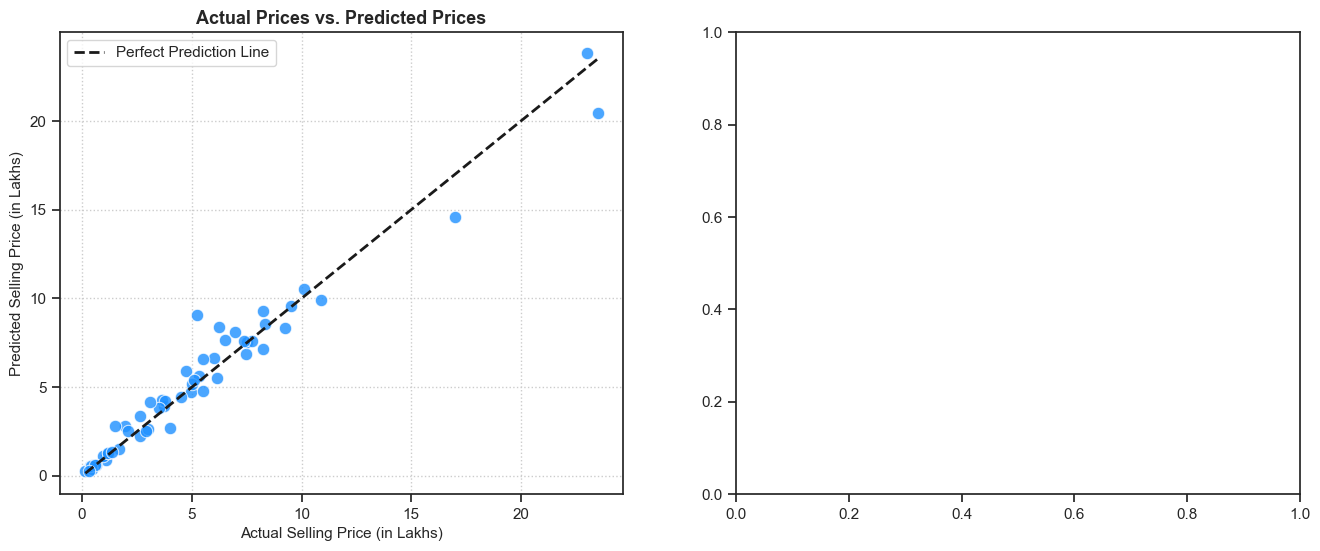

In [11]:


fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Prediction Accuracy Scatter Graph
sns.scatterplot(x=y_test, y=y_pred, alpha=0.8, color='dodgerblue', edgecolor='w', s=80, ax=axes[0])
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2, label='Perfect Prediction Line')
axes[0].set_title('Actual Prices vs. Predicted Prices', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Actual Selling Price (in Lakhs)', fontsize=11)
axes[0].set_ylabel('Predicted Selling Price (in Lakhs)', fontsize=11)
axes[0].legend()
axes[0].grid(True, linestyle=':')



In [12]:
# Plot 2: Residuals Error Distribution
residuals = y_test - y_pred
sns.histplot(residuals, kde=True, color='purple', bins=15, ax=axes[1])
axes[1].axvline(0, color='black', linestyle='--', lw=2)
axes[1].set_title('Residuals (Prediction Error) Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Error Deviation (Actual - Predicted)', fontsize=11)
axes[1].set_ylabel('Density Frequency', fontsize=11)
axes[1].grid(True, linestyle=':')

plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>